In [19]:
#import the libraries

!pip install torch torchvision

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
from tqdm import tqdm 

In [26]:
class SingleRNN(nn.Module):
    def __init__(self,n_inputs,n_neurons):
        super(SingleRNN,self).__init__()
        
        self.Wx=torch.randn(n_inputs,n_neurons) # 4*1
        self.Wy=torch.randn(n_neurons,n_neurons) # 1*1
        
        self.b = torch.zeros(1,n_neurons) # 1*4
        
    def forward(self,X0,X1):
        self.Y0=torch.tanh(torch.mm(X0,self.Wx)+self.b) # 4*1
        self.Y1=torch.tanh(torch.mm(self.Y0,self.Wy)+torch.mm(X1,self.Wx)+self.b) #4*1
        
        return self.Y0,self.Y1

In [27]:
N_INPUTS = 4
N_NEURONS = 1

X0_batch = torch.tensor([[0,1,2,0],[3,4,5,0],[6,7,8,0],[9,0,1,0]],dtype=torch.float)
X1_batch = torch.tensor([[9,8,7,0],[0,0,0,0],[6,5,4,0],[3,2,1,0]],dtype=torch.float)

model=SingleRNN(N_INPUTS,N_NEURONS)

Y0_val,Y1_val = model(X0_batch,X1_batch)

In [28]:
print("Y0_val:",Y0_val)
print("Y1_val:",Y1_val)

Y0_val: tensor([[ 0.9422],
        [ 0.9987],
        [ 1.0000],
        [-0.6579]])
Y1_val: tensor([[ 0.9993],
        [-0.0477],
        [ 0.9672],
        [ 0.1973]])


In [30]:
class BasicRNN(nn.Module):
    def __init__(self,n_inputs,n_neurons):
        super(BasicRNN,self).__init__()
        
        self.Wx=torch.randn(n_inputs,n_neurons) # 4*1
        self.Wy=torch.randn(n_neurons,n_neurons) # 1*1
        
        self.b = torch.zeros(1,n_neurons) # 1*4
        
    def forward(self,X0,X1):
        self.Y0=torch.tanh(torch.mm(X0,self.Wx)+self.b) # 4*1
        self.Y1=torch.tanh(torch.mm(self.Y0,self.Wy)+torch.mm(X1,self.Wx)+self.b) #4*1
        
        return self.Y0,self.Y1

In [33]:
N_INPUTS = 3
N_NEURONS = 5

X0_batch = torch.tensor([[0,1,2],[3,4,5],[6,7,8],[9,0,1]],dtype=torch.float)
X1_batch = torch.tensor([[9,8,7],[0,0,0],[6,5,4],[3,2,1]],dtype=torch.float)

model=SingleRNN(N_INPUTS,N_NEURONS)

Y0_val,Y1_val = model(X0_batch,X1_batch)

In [34]:
print("Y0_val:",Y0_val)
print("Y1_val:",Y1_val)

Y0_val: tensor([[ 0.9053,  0.8884, -0.1057, -0.7465,  0.7116],
        [-0.4137,  0.6854, -0.9595,  1.0000,  0.9858],
        [-0.9830,  0.2579, -0.9989,  1.0000,  0.9994],
        [-1.0000, -1.0000, -0.9999,  1.0000,  1.0000]])
Y1_val: tensor([[-1.0000e+00, -9.9697e-01, -9.9642e-01,  1.0000e+00, -6.4611e-05],
        [-9.9921e-01,  8.7712e-01,  3.0639e-01, -9.7948e-01, -9.7569e-01],
        [-1.0000e+00, -7.5832e-01, -9.9806e-01,  1.0000e+00,  7.7339e-01],
        [-9.9984e-01,  8.8095e-01, -6.5954e-01,  1.0000e+00,  9.6492e-01]])


In [40]:
rnn = nn.RNNCell(3,5)

X_batch = torch.tensor([[[0,1,2],[3,4,5],[6,7,8],[9,0,1]],
                        [[9,8,7],[0,0,0],[6,5,4],[3,2,1]]],dtype=torch.float)


hx=torch.randn(4,5)

output = []
for i in range(2):
    hx=rnn(X_batch[i],hx)
    output.append(hx)
    
print(output)

[tensor([[ 0.0245, -0.8460, -0.7661,  0.3239, -0.9490],
        [-0.7134, -0.1271, -0.6380, -0.7719, -0.9996],
        [-0.7201, -0.4990, -0.8983, -0.9184, -1.0000],
        [-0.9965,  0.9911,  0.9992, -0.4243, -0.8650]],
       grad_fn=<TanhBackward0>), tensor([[-0.9787,  0.7235,  0.1914, -0.9908, -0.9999],
        [ 0.1797, -0.5544, -0.3412,  0.2610, -0.7988],
        [-0.9188,  0.7113,  0.4195, -0.9290, -0.9991],
        [-0.8981,  0.5494, -0.3030, -0.9610, -0.8666]],
       grad_fn=<TanhBackward0>)]


In [41]:
import torchvision
import torchvision.transforms as transforms

In [42]:
BATCH_SIZE = 64

# list all transformations
transform = transforms.Compose(
    [transforms.ToTensor()])
# download and load training dataset
trainset = torchvision.datasets.MNIST(root='./data', train=True,download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,shuffle=True, num_workers=0)
# download and load testing dataset

testset = torchvision.datasets.MNIST(root='./data', train=False,download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,shuffle=False, num_workers=0)

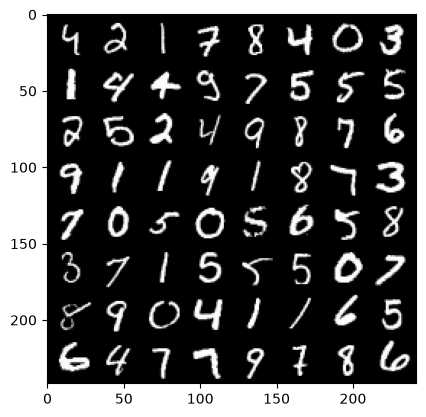

In [43]:
import matplotlib.pyplot as plt
import numpy as np
# functions to show an image
def imshow(img):
    #img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
# get some random training images
data_iter = iter(trainloader)
images, labels = next(data_iter)
# show images
imshow(torchvision.utils.make_grid(images))